# Step-by-step Image Processing

This goes through the transformation of one screenshot into the individual emojis it contains.

The process is as follows:
1. Use the cv2 library to import the image
2. Crop the image to only show the emojis
3. Resize the image to create enlarged individual emojis
4. Save the emojis to new folder location

## Import relevant libraries

In [132]:
import cv2
import statistics
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_prominences
from datetime import datetime

## Read the Screenshot Image
Use cv2 to read the image into python, applying the RGB colour channels

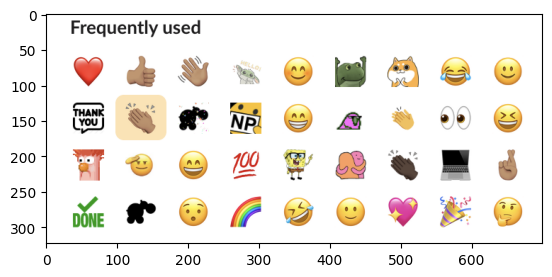

In [ ]:
# cv2.imread reads the image in BGR format, so we need to convert it to RGB for displaying with matplotlib
filename = 'fuse_20260907_094858.png'
img = cv2.imread(f'Resource/fuse_screenshots/' + {filename})

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

In the Screenshot_processing.ipynb file on the emoji sentiment analysis repo, there is a step to halve the images (where necessary) by identifying a border using the green line in WhatsApp.
This step may be applicable to images that include "Frequently used" above the emoji list.

`img.shape` returns a tuple of the number of rows, columns, and channels (if the image is colour, if not only rows and columns are returned)

Above, we are asking how many times does 2 go into the number of rows in the image i.e. halving it

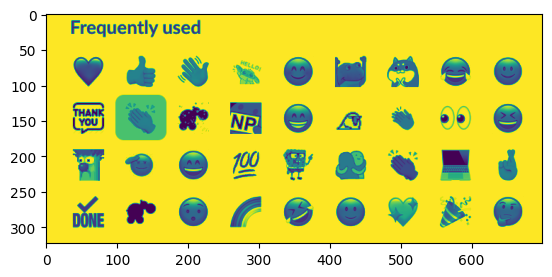

In [60]:
blue_img = img[:,:,0]
plt.imshow(blue_img)  # Displaying the blue channel
plt.show()

### Screenshot Shape

In [61]:
screenshot_rows = blue_img.shape[0]
screenshot_cols = blue_img.shape[1]

print(f"""Rows: {screenshot_rows}
Columns: {screenshot_cols}""")

Rows: 323
Columns: 700


### Explanation of image slicing
1. `img.shape` returns (291, 682, 3) which means the image has 291 rows, 682 columns, and 3 color channels (BGR)
2. `img[:,:,0]` returns the blue channel of the image, which is a 2D array of shape (291, 682)
3. `img[:,:,0][18, 38]` returns the pixel value at row 18, column 38 of the blue channel

### Find the left side boundary

In [62]:
# for the cols
# while the array is empty, keep looping until a non-empty array is found

l_array_len = 0
li = 0

# while l_empty_array and l_array_len < 5:
while l_array_len < 5:
    img_col = blue_img[:, li]
    l_col_peaks, _ = find_peaks(img_col)
    l_prominent_peaks = peak_prominences(img_col, l_col_peaks)[1]
    l_array_len = len(l_prominent_peaks)

    li += 1

left_peak = li
left_boundary = left_peak - 30

In [63]:
left_cropped_pct = (left_boundary / screenshot_cols) * 100.00
print(f"% of screenshot cropped on left: {left_cropped_pct}")

% of screenshot cropped on left: 1.2857142857142856


### Find the right side boundary

In [64]:
# for the cols
# while the array is empty, keep looping until a non-empty array is found

r_array_len = 0
ri = -1

while r_array_len < 5:
    img_col = blue_img[:, ri]
    r_col_peaks, _ = find_peaks(img_col)
    r_prominent_peaks = peak_prominences(img_col, r_col_peaks)[1]
    r_array_len = len(r_prominent_peaks)

    ri -= 1

right_peak = ri
right_boundary = blue_img.shape[1] + right_peak + 10

In [65]:
right_cropped_pct = 100 - (right_boundary / screenshot_cols) * 100.00
print(f"% of screenshot cropped on right: {right_cropped_pct}")

% of screenshot cropped on right: 2.5714285714285694


### Find the top boundary

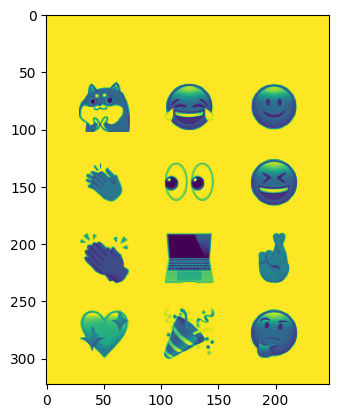

In [66]:
hlf_img = int(906 / 2)
img_halved = blue_img[:, hlf_img:]
plt.imshow(img_halved)

In [67]:
# for the cols
# while the array is empty, keep looping until a non-empty array is found

t_array_len = True
ti = 0
# col_search = right_boundary + right_peak

while t_array_len < 5:
    img_col = img_halved[ti]
    # img_col = blue_img[ti, col_search : right_boundary]
    t_col_peaks, _ = find_peaks(img_col)
    t_prominent_peaks = peak_prominences(img_col, t_col_peaks)[1]
    t_array_len = len(t_prominent_peaks)

    ti += 1

top_peak = ti
top_boundary = top_peak - 30

In [68]:
top_cropped_pct = (top_boundary / screenshot_cols) * 100.00
print(f"% of screenshot cropped on top: {top_cropped_pct}")

% of screenshot cropped on top: 4.428571428571428


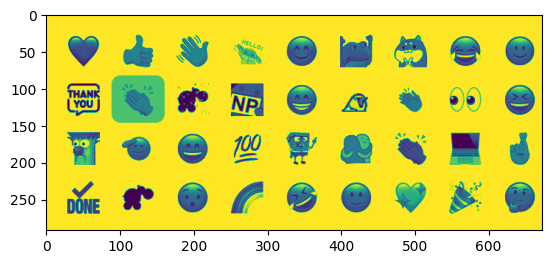

In [69]:
plt.imshow(blue_img[top_boundary:, left_boundary:right_boundary])
plt.show()

### Find the bottom boundary

In [70]:
# for the cols
# while the array is empty, keep looping until a non-empty array is found

b_array_len = 0
bi = -1

while b_array_len < 5:
    img_col = blue_img[bi,:]
    b_col_peaks, _ = find_peaks(img_col)
    b_prominent_peaks = peak_prominences(img_col, b_col_peaks)[1]
    b_array_len = len(b_prominent_peaks)

    bi -= 1

bottom_peak = bi
bottom_boundary = blue_img.shape[0] - bottom_peak - 10

In [71]:
bottom_cropped_pct = 100 - (bottom_boundary / screenshot_cols) * 100.00
print(f"% of screenshot cropped on bottom: {bottom_cropped_pct}")

% of screenshot cropped on bottom: 51.857142857142854


#### All Boundaries

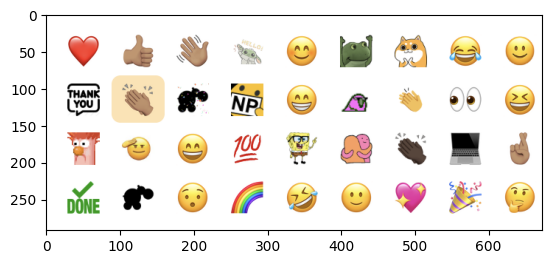

In [72]:
cropped_img = img[top_boundary:bottom_boundary, left_boundary:right_boundary]
plt.imshow(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))
plt.show()

## Create Function Identifying Cropping Bounds

In [88]:
cropped_blue_img = cropped_img[:,:,0]

In [90]:
cropped_rows = cropped_blue_img.shape[0]
cropped_cols = cropped_blue_img.shape[1]

If the length of the array is less than 5 then add it to a "zero_block"

If the length of the array is more than 5 then add it to a "block"

Maintain the previous block type array and if it is the same block type array, keep adding it to the same block, otherwise, add to a new block.

### Get the number of emoji rows

In [115]:
empty_row_blocks = 0
occ_row_blocks = 0
prev_row_peaks = 999

for i in range(cropped_rows):
    row_pixels = cropped_blue_img[i]
    peaks = find_peaks(row_pixels)[0]
    peak_len = len(peaks)

    if peak_len < 5 and prev_row_peaks >= 5:
        empty_row_blocks += 1
        prev_row_peaks = peak_len
    elif peak_len >= 5 and prev_row_peaks < 5:
        occ_row_blocks += 1
        prev_row_peaks = peak_len
    else:
        continue

### Get the number of emoji columns

In [113]:
empty_col_blocks = 0
occ_col_blocks = 0
prev_col_peaks = 999

for i in range(cropped_cols):
    col_pixels = cropped_blue_img[:, i]
    peaks = find_peaks(col_pixels)[0]
    peak_len = len(peaks)

    if peak_len < 5 and prev_col_peaks >= 5:
        empty_col_blocks += 1
        prev_col_peaks = peak_len
    elif peak_len >= 5 and prev_col_peaks < 5:
        occ_col_blocks += 1
        prev_col_peaks = peak_len
    else:
        continue

### Estimate Emoji box dimensions

In [117]:
box_cols = int(cropped_cols / occ_col_blocks)
box_rows = int(cropped_rows / occ_row_blocks)

box_cols, box_rows

(74, 73)

In [123]:
r_start = 0
r_end = box_rows
c_start = 0
c_end = box_cols
emoji_list = []

for i in range(occ_row_blocks):
    c_start = 0
    c_end = box_cols

    for i in range(occ_col_blocks):
        new_img = cropped_img[r_start:r_end, c_start:c_end]

        emoji_list.append(new_img)

        c_start = c_end
        c_end += box_cols

    r_start = r_end
    r_end += box_rows

In [130]:
len(emoji_list)

36

In [ ]:
random_int = np.random.randint(1000, 10000)
current_datetime = datetime.utcnow().strftime('%Y%m%d_%H%M%S')

new_filename = f"{current_datetime}_{random_int}.png"

target_folder = "Resource\fuse_emoji_imgs"

'20260924_111631_3938.png'

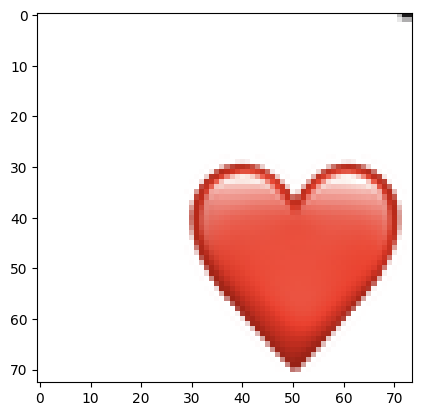

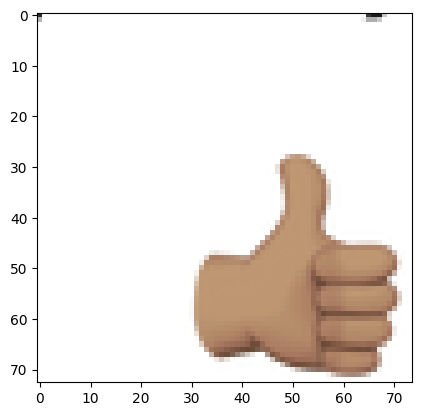

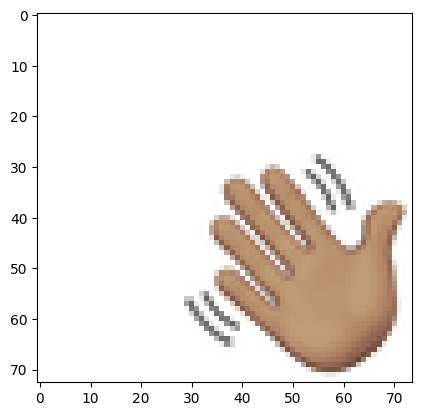

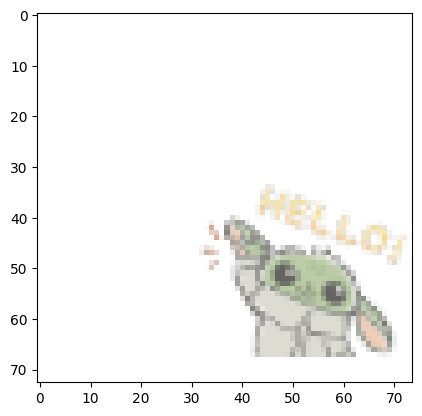

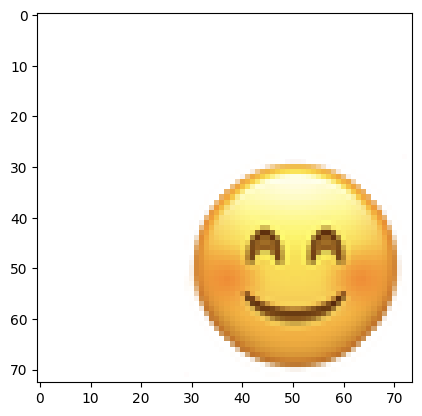

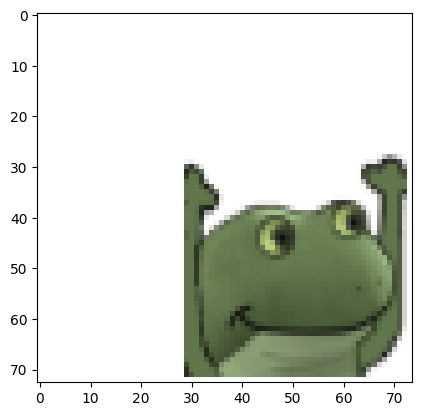

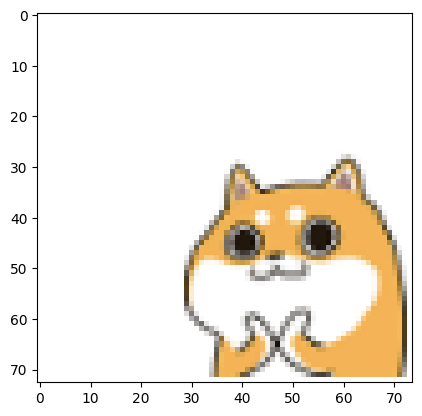

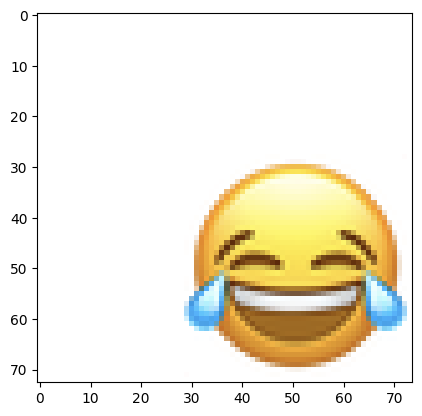

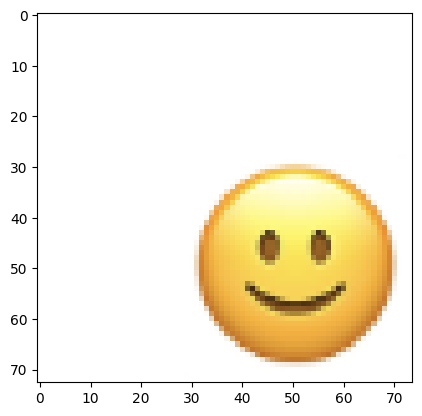

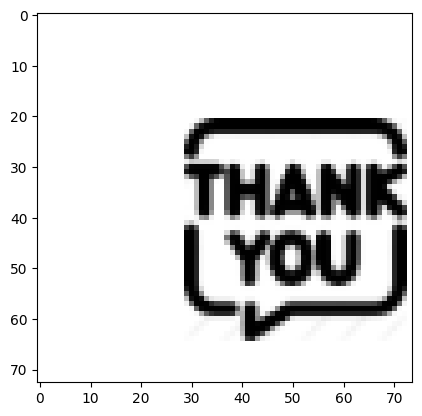

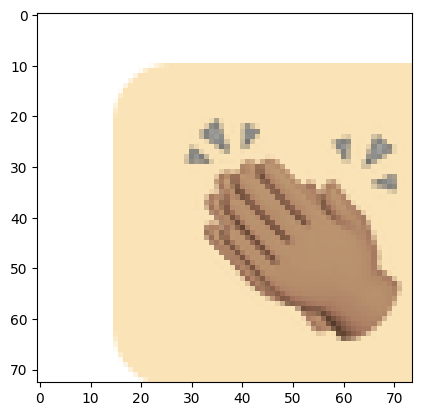

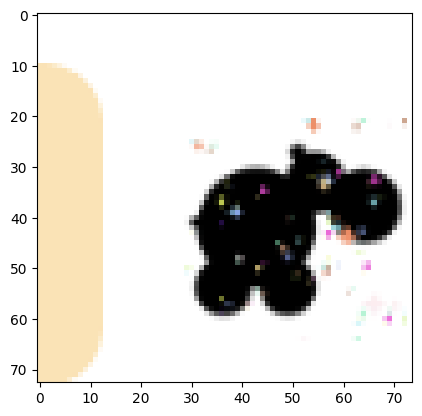

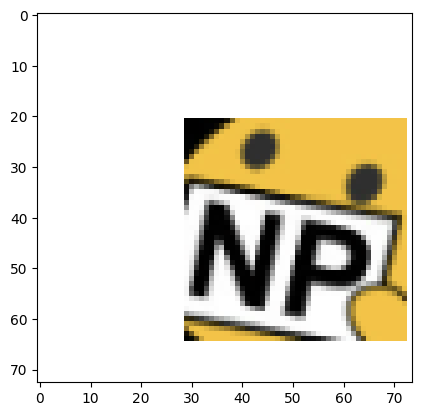

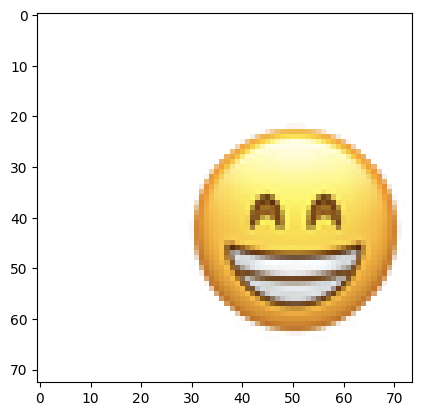

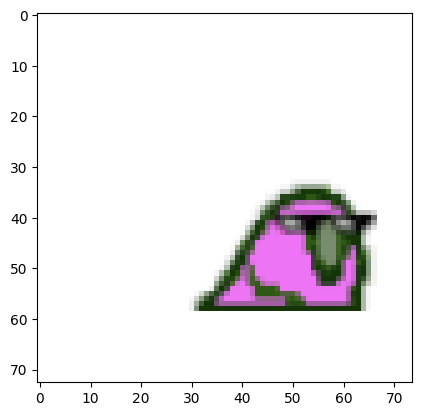

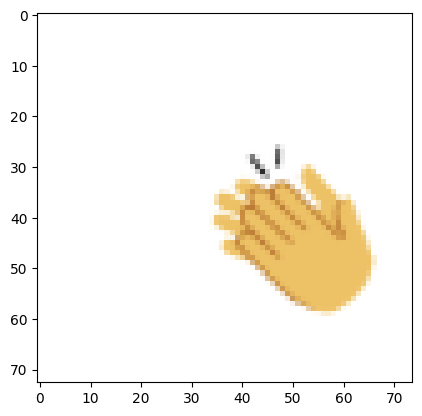

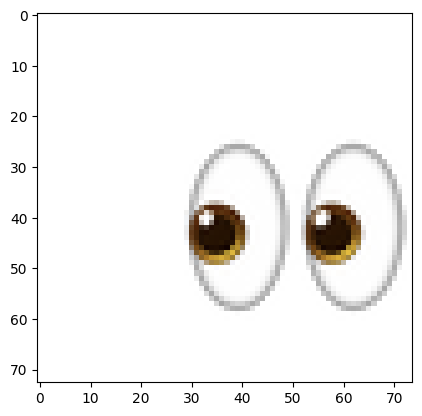

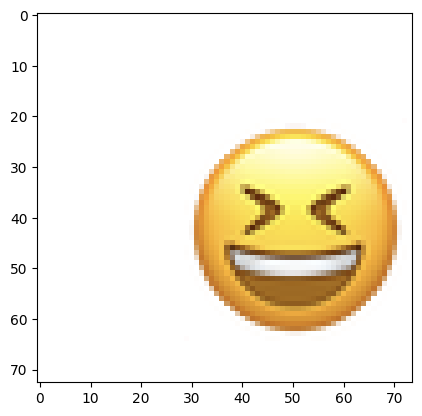

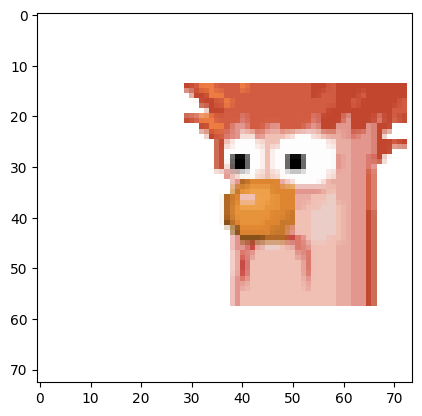

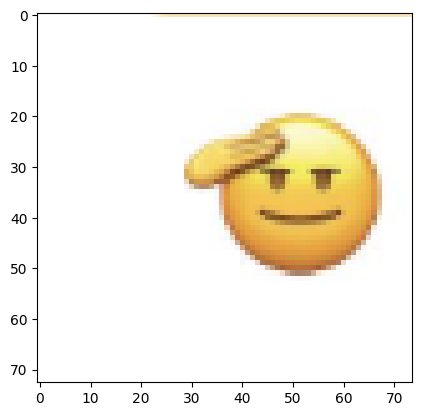

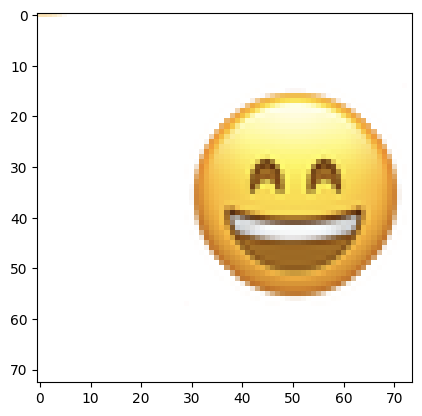

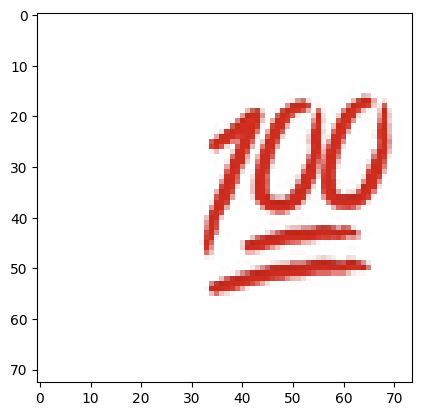

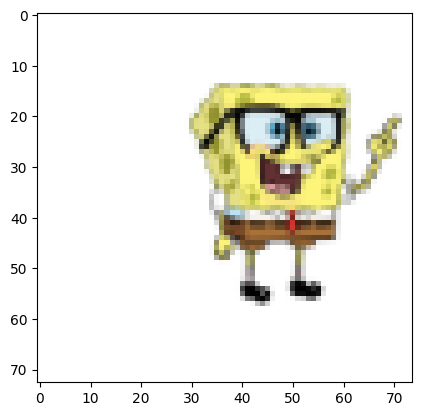

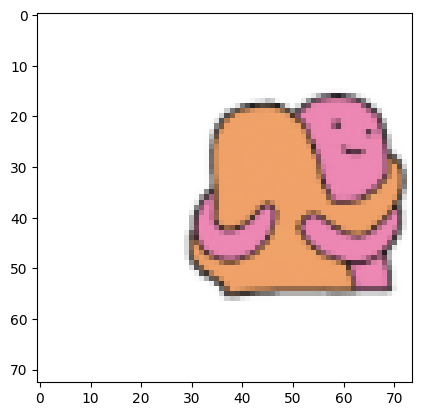

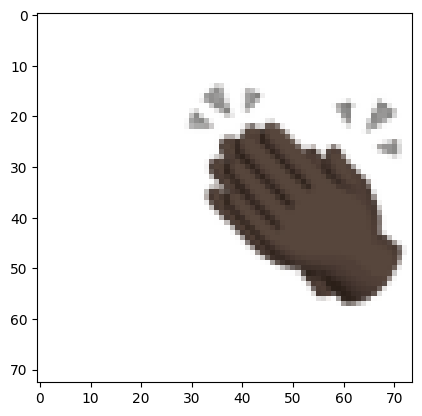

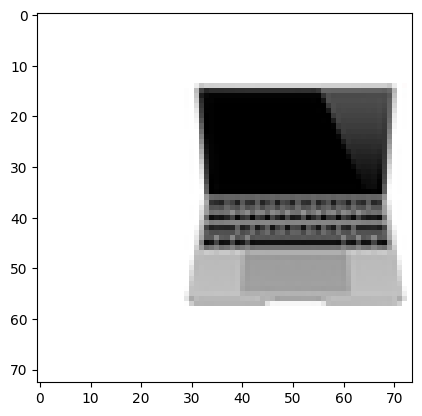

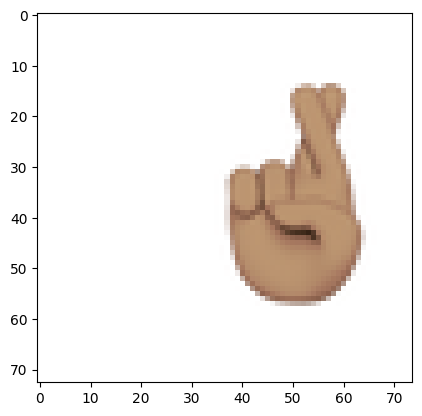

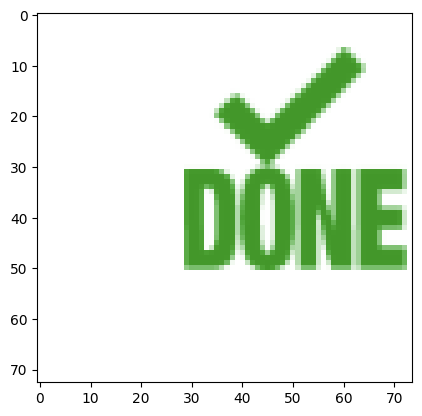

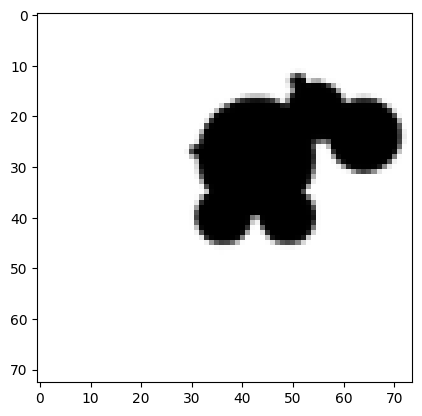

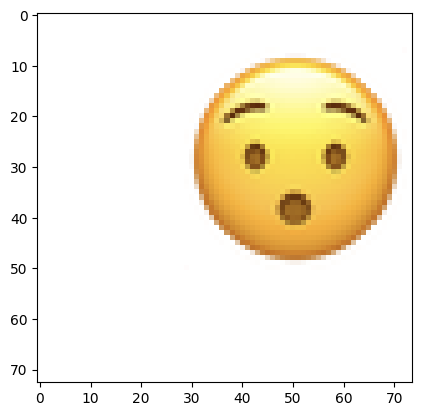

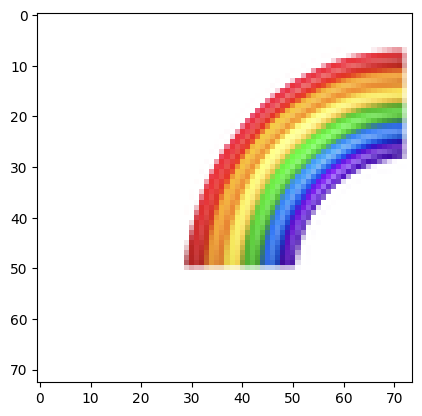

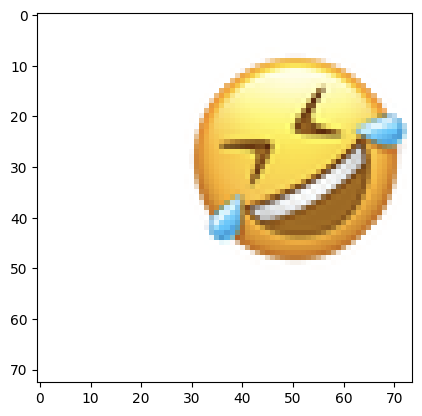

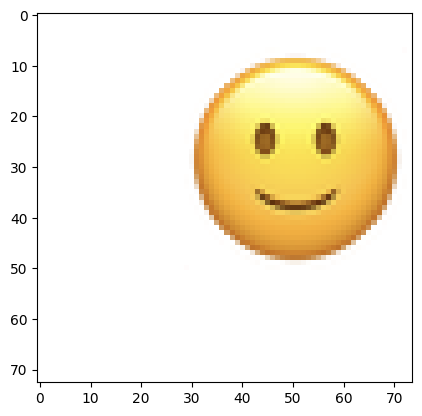

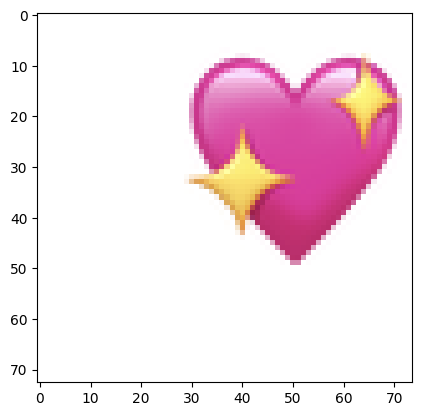

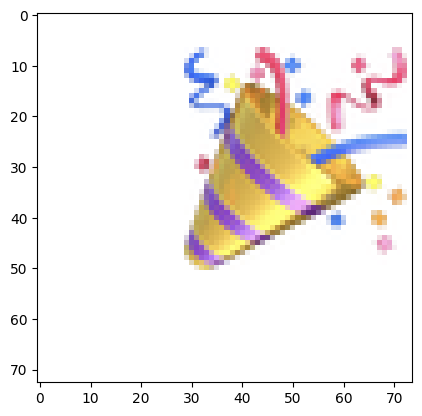

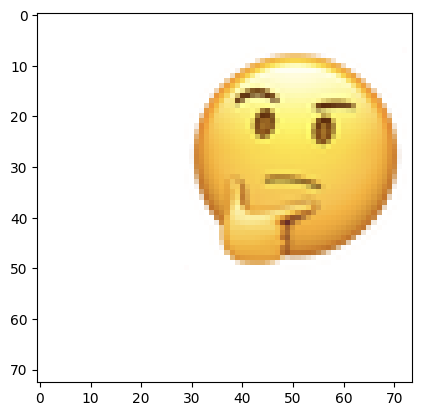

In [131]:
for i in range(len(emoji_list)):
    plt.imshow(cv2.cvtColor(emoji_list[i], cv2.COLOR_BGR2RGB))
    plt.show()